# Policy Testing — Result Analysis

Paper-style visualisation of the OFAT sensitivity sweeps produced by
`testing/evaluate_policy.py`. This notebook reads **only the CSV files** under
`testing_results/csv/` (no model, no environment) and writes publication-ready
PNG figures to `testing_results/plots/`.

**Inputs**  `agg_<axis>.csv`, `detail_<axis>.csv`, `agg_epoch.csv`,
`heatmap_<pair>.csv`.
**Outputs** `fig_<axis>.png`, `fig_epoch.png`, `fig_heatmap_<pair>.png`.

Each per-axis figure carries six panels — success rate (with Wilson 95 % CI),
mean return, final coverage, SPL, steps-to-success, and cooperation — with the
out-of-distribution region shaded and the training-range boundary marked.

In [1]:
import os, glob, math
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# Locate the repo root so the notebook works whether it is launched from the
# project root or from inside testing/ (nbconvert sets cwd to the notebook dir).
def _find_root(start):
    d = os.path.abspath(start)
    for _ in range(6):
        if os.path.exists(os.path.join(d, "configs", "default.yaml")):
            return d
        d = os.path.dirname(d)
    return os.path.abspath(start)

ROOT     = _find_root(os.getcwd())
CSV_DIR  = os.path.join(ROOT, "testing_results", "csv")
PLOT_DIR = os.path.join(ROOT, "testing_results", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(CSV_DIR,  exist_ok=True)

# ---- publication style ----------------------------------------------------
mpl.rcParams.update({
    "figure.dpi":        120,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif", "STIXGeneral"],
    "mathtext.fontset":  "stix",
    "font.size":         9,
    "axes.titlesize":    10,
    "axes.labelsize":    9.5,
    "axes.linewidth":    0.8,
    "axes.grid":         True,
    "grid.linewidth":    0.5,
    "grid.alpha":        0.35,
    "lines.linewidth":   1.7,
    "lines.markersize":  5,
    "legend.fontsize":   8,
    "legend.frameon":    True,
    "legend.framealpha": 0.92,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "xtick.direction":   "in",
    "ytick.direction":   "in",
})

C_ID  = "#1f4e79"   # in-distribution
C_OOD = "#c0392b"   # out-of-distribution
C_2   = "#2e8b57"   # secondary series

AXIS_LABEL = {
    "n_agents":  r"number of drones $N$",
    "vision":    r"vision radius $v$",
    "comm":      r"communication range $c$",
    "density":   r"obstacle density $\rho$",
    "max_steps": r"step budget $T$",
    "epoch":     "training episode",
}

def load_agg(axis):
    p = os.path.join(CSV_DIR, f"agg_{axis}.csv")
    return pd.read_csv(p).sort_values("value").reset_index(drop=True) if os.path.exists(p) else None

print("CSV files found:", sorted(os.path.basename(p) for p in glob.glob(os.path.join(CSV_DIR, '*.csv'))))

CSV files found: ['agg_comm.csv', 'agg_density.csv', 'agg_epoch.csv', 'agg_fault.csv', 'agg_max_steps.csv', 'agg_n_agents.csv', 'agg_vision.csv', 'detail_comm.csv', 'detail_density.csv', 'detail_epoch.csv', 'detail_fault.csv', 'detail_max_steps.csv', 'detail_n_agents.csv', 'detail_vision.csv', 'heatmap_nagents_comm.csv', 'heatmap_vision_density.csv']


## 1 — Per-axis sensitivity figures

One figure per swept factor. Filled circles = in-distribution (values seen during
training); open red squares = **out-of-distribution** extrapolation. The grey band
and dashed lines delimit the training range.

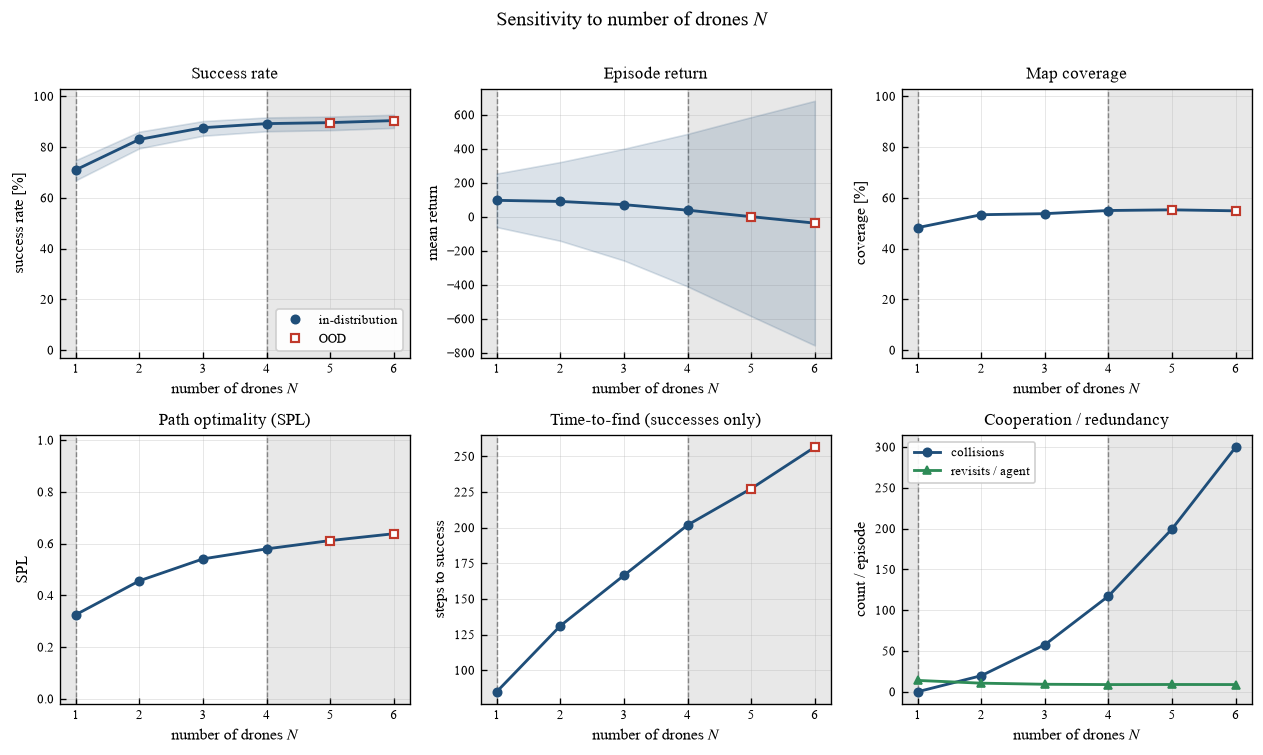

  saved c:\Users\simon\OneDrive - Alma Mater Studiorum Università di Bologna\Corsi\Artificial Intelligence\II Anno\II Semestre\Multi-Agent Systems\Multi-Agent-Systems-Project\testing_results\plots\fig_n_agents.png


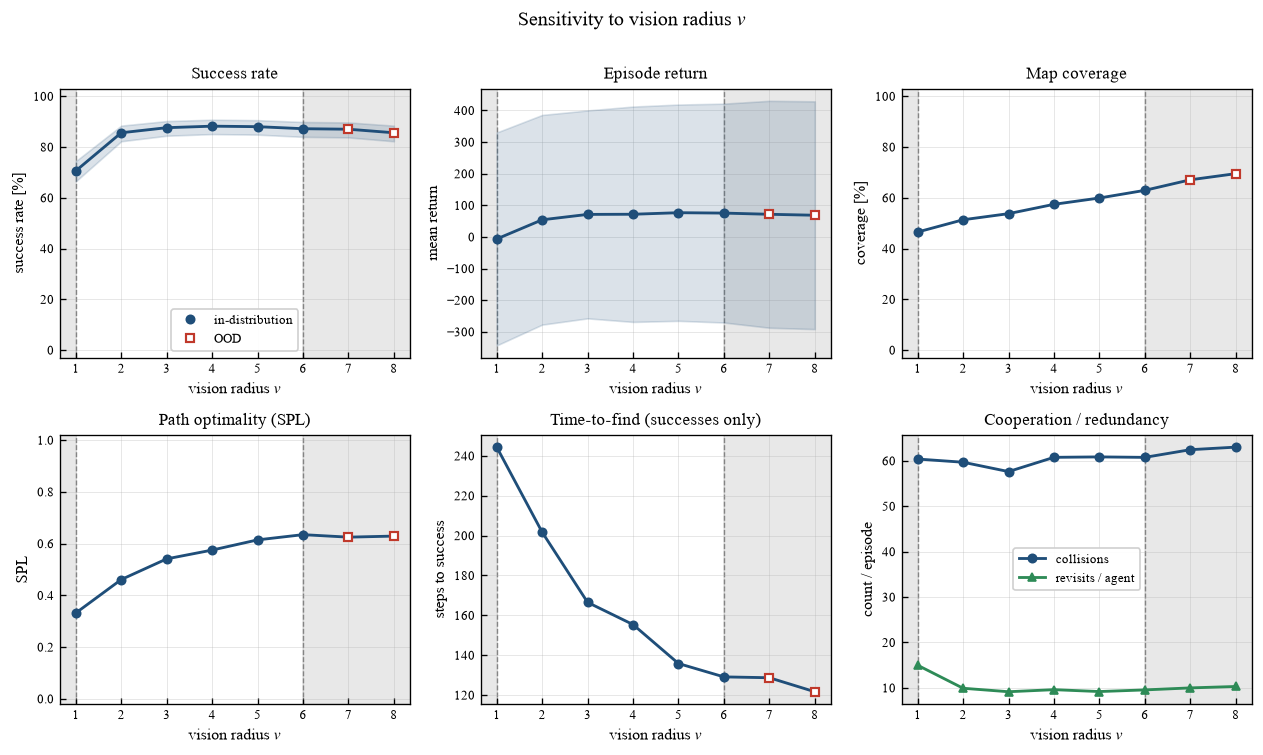

  saved c:\Users\simon\OneDrive - Alma Mater Studiorum Università di Bologna\Corsi\Artificial Intelligence\II Anno\II Semestre\Multi-Agent Systems\Multi-Agent-Systems-Project\testing_results\plots\fig_vision.png


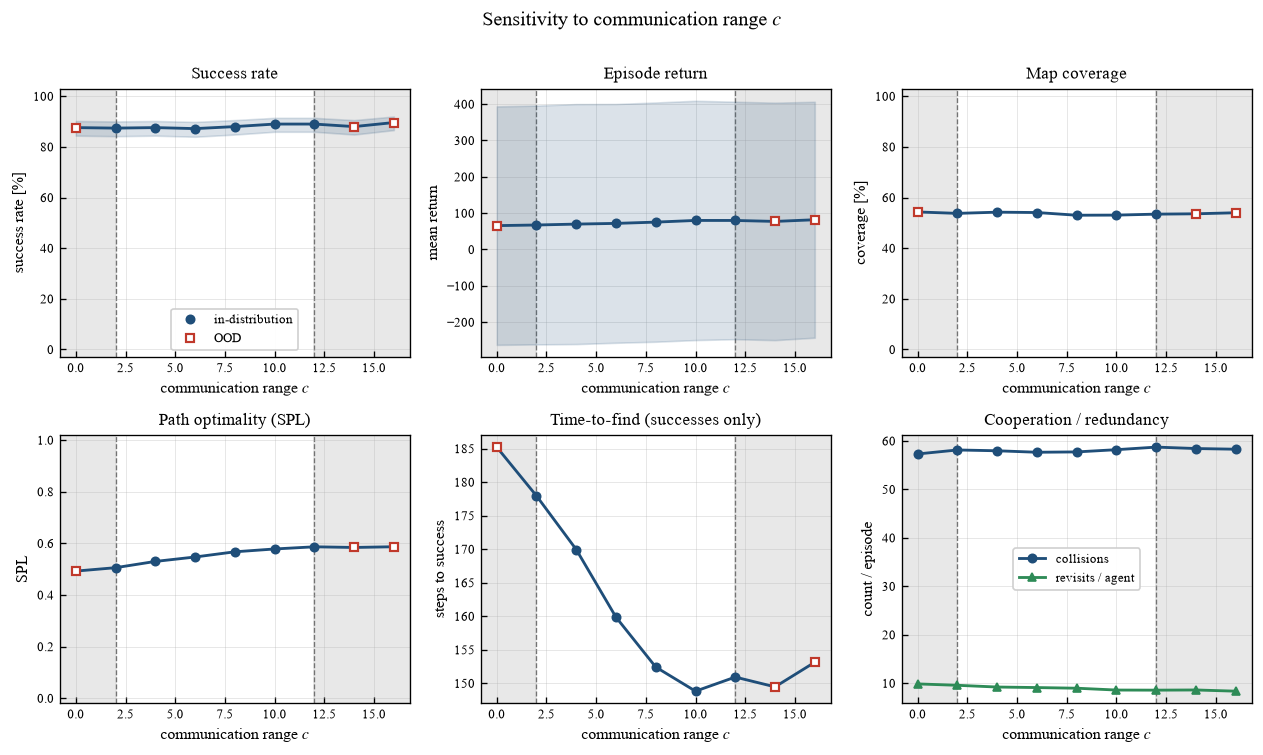

  saved c:\Users\simon\OneDrive - Alma Mater Studiorum Università di Bologna\Corsi\Artificial Intelligence\II Anno\II Semestre\Multi-Agent Systems\Multi-Agent-Systems-Project\testing_results\plots\fig_comm.png


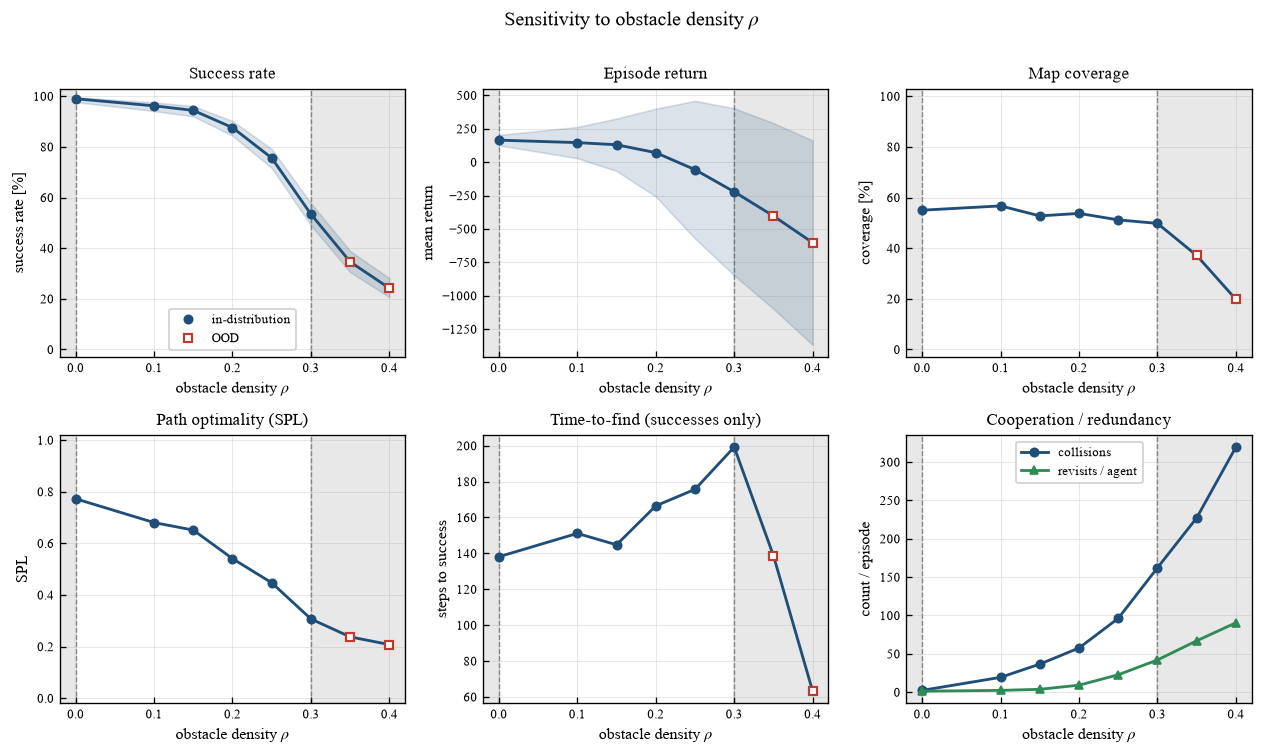

  saved c:\Users\simon\OneDrive - Alma Mater Studiorum Università di Bologna\Corsi\Artificial Intelligence\II Anno\II Semestre\Multi-Agent Systems\Multi-Agent-Systems-Project\testing_results\plots\fig_density.png


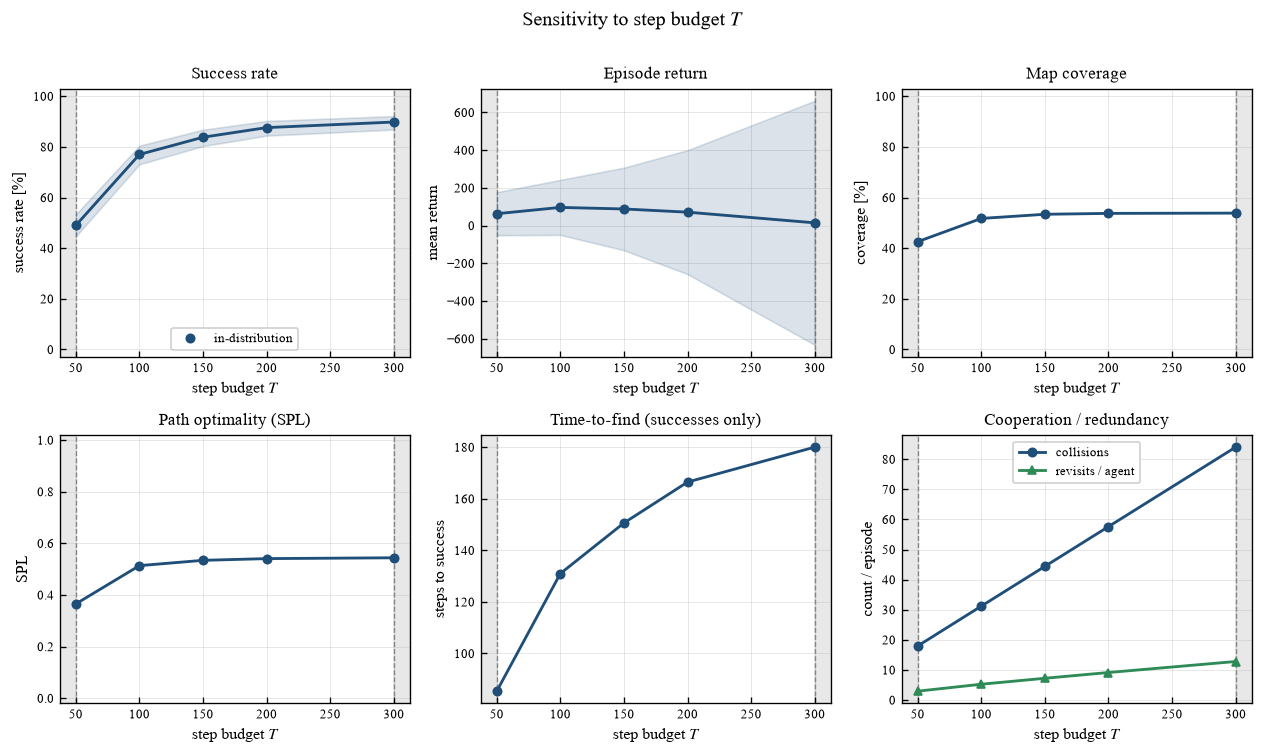

  saved c:\Users\simon\OneDrive - Alma Mater Studiorum Università di Bologna\Corsi\Artificial Intelligence\II Anno\II Semestre\Multi-Agent Systems\Multi-Agent-Systems-Project\testing_results\plots\fig_max_steps.png


In [2]:
def _shade_ood(ax, df):
    idv = df.loc[df.in_dist == 1, "value"]
    if idv.empty:
        return
    lo, hi = idv.min(), idv.max()
    x0, x1 = ax.get_xlim()
    if lo > x0: ax.axvspan(x0, lo, color="0.85", alpha=0.6, zorder=0)
    if hi < x1: ax.axvspan(hi, x1, color="0.85", alpha=0.6, zorder=0)
    ax.axvline(lo, ls="--", lw=0.8, color="0.45", zorder=1)
    ax.axvline(hi, ls="--", lw=0.8, color="0.45", zorder=1)
    ax.set_xlim(x0, x1)

def _metric(ax, df, y, ylabel, title, band=None, shade=True):
    y   = np.asarray(y, dtype=float)
    idm = (df.in_dist == 1).values
    ax.plot(df.value, y, "-", color=C_ID, zorder=3)
    if band is not None:
        ax.fill_between(df.value, band[0], band[1], color=C_ID, alpha=0.16, zorder=2)
    ax.plot(df.value[idm],  y[idm],  "o", color=C_ID, zorder=4, label="in-distribution")
    if (~idm).any():
        ax.plot(df.value[~idm], y[~idm], "s", mfc="white", mec=C_OOD,
                color=C_OOD, mew=1.3, zorder=4, label="OOD")
    ax.set_ylabel(ylabel); ax.set_title(title)
    if shade: _shade_ood(ax, df)

def plot_axis(axis):
    df = load_agg(axis)
    if df is None:
        print("  (skip, no CSV):", axis); return
    xl = AXIS_LABEL.get(axis, axis)
    fig, axs = plt.subplots(2, 3, figsize=(10.6, 6.2))

    _metric(axs[0,0], df, df.success_rate*100, "success rate [%]", "Success rate",
            band=(df.wilson_lo*100, df.wilson_hi*100))
    axs[0,0].set_ylim(-3, 103); axs[0,0].legend(loc="best")

    _metric(axs[0,1], df, df.mean_reward, "mean return", "Episode return",
            band=(df.mean_reward - df.std_reward, df.mean_reward + df.std_reward))

    _metric(axs[0,2], df, df.coverage*100, "coverage [%]", "Map coverage")
    axs[0,2].set_ylim(-3, 103)

    _metric(axs[1,0], df, df.spl, "SPL", "Path optimality (SPL)")
    axs[1,0].set_ylim(-0.02, 1.02)

    m = df.ttf_n > 0
    _metric(axs[1,1], df[m].reset_index(drop=True),
            df[m].ttf, "steps to success", "Time-to-find (successes only)")

    ax = axs[1,2]
    ax.plot(df.value, df.collisions, "-o", color=C_ID, label="collisions")
    ax.plot(df.value, df.revisits,  "-^", color=C_2,  label="revisits / agent")
    ax.set_ylabel("count / episode"); ax.set_title("Cooperation / redundancy")
    ax.legend(loc="best"); _shade_ood(ax, df)

    for ax in axs.ravel():
        ax.set_xlabel(xl)
    fig.suptitle(f"Sensitivity to {xl}", fontsize=12, y=1.005)
    fig.tight_layout()
    out = os.path.join(PLOT_DIR, f"fig_{axis}.png")
    fig.savefig(out); plt.show(); print("  saved", out)

for axis in ["n_agents", "vision", "comm", "density", "max_steps"]:
    plot_axis(axis)

## 2 — Learning curve over training

The reference operating point evaluated at every checkpoint
(`agg_epoch.csv`). Shows how success, return, coverage and path optimality
evolve with training episodes on the held-out test maps.

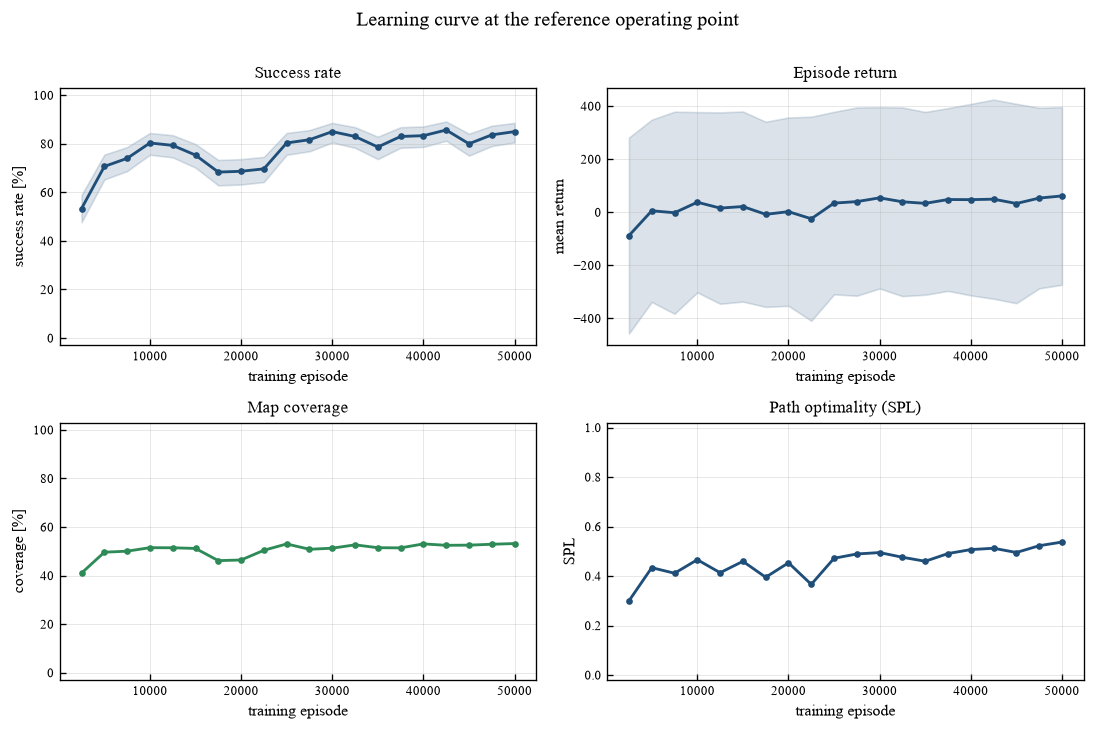

  saved c:\Users\simon\OneDrive - Alma Mater Studiorum Università di Bologna\Corsi\Artificial Intelligence\II Anno\II Semestre\Multi-Agent Systems\Multi-Agent-Systems-Project\testing_results\plots\fig_epoch.png


In [3]:
def plot_epoch():
    df = load_agg("epoch")
    if df is None:
        print("  (skip) no agg_epoch.csv"); return
    fig, axs = plt.subplots(2, 2, figsize=(9.2, 6.0))
    x = df.value

    axs[0,0].fill_between(x, df.wilson_lo*100, df.wilson_hi*100, color=C_ID, alpha=0.16)
    axs[0,0].plot(x, df.success_rate*100, "-o", color=C_ID, ms=3)
    axs[0,0].set_ylabel("success rate [%]"); axs[0,0].set_title("Success rate"); axs[0,0].set_ylim(-3,103)

    axs[0,1].fill_between(x, df.mean_reward-df.std_reward, df.mean_reward+df.std_reward, color=C_ID, alpha=0.16)
    axs[0,1].plot(x, df.mean_reward, "-o", color=C_ID, ms=3); axs[0,1].set_ylabel("mean return")
    axs[0,1].set_title("Episode return")

    axs[1,0].plot(x, df.coverage*100, "-o", color=C_2, ms=3); axs[1,0].set_ylabel("coverage [%]")
    axs[1,0].set_title("Map coverage"); axs[1,0].set_ylim(-3,103)

    axs[1,1].plot(x, df.spl, "-o", color=C_ID, ms=3); axs[1,1].set_ylabel("SPL")
    axs[1,1].set_title("Path optimality (SPL)"); axs[1,1].set_ylim(-0.02,1.02)

    for ax in axs.ravel():
        ax.set_xlabel("training episode")
    fig.suptitle("Learning curve at the reference operating point", fontsize=12, y=1.005)
    fig.tight_layout()
    out = os.path.join(PLOT_DIR, "fig_epoch.png")
    fig.savefig(out); plt.show(); print("  saved", out)

plot_epoch()

## 3 — Interaction heatmaps

Two targeted 2-D grids (`heatmap_*.csv`): how pairs of factors interact, which a
one-factor-at-a-time sweep cannot reveal. Cells annotated with success rate.

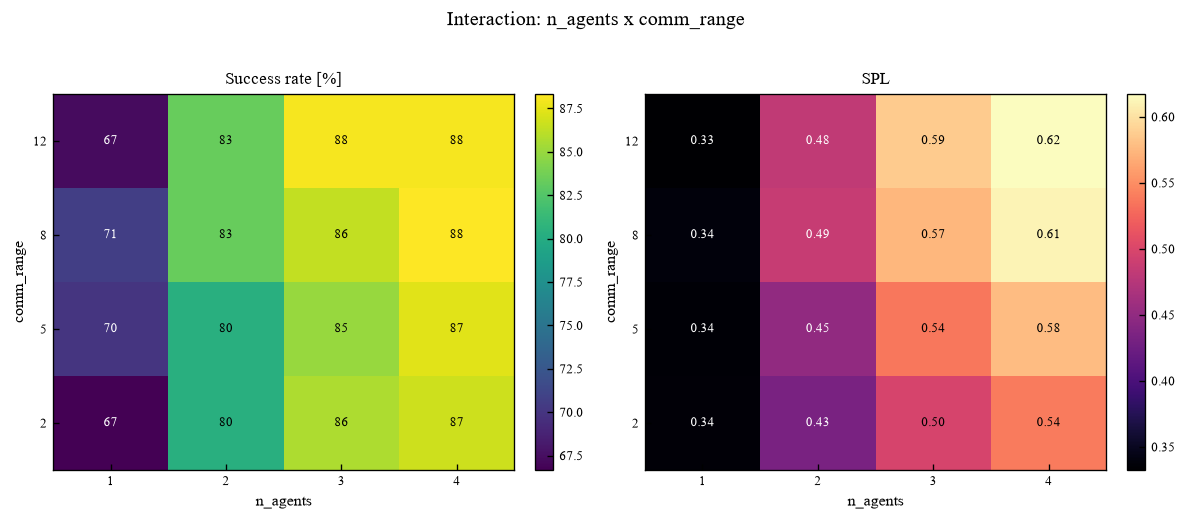

  saved c:\Users\simon\OneDrive - Alma Mater Studiorum Università di Bologna\Corsi\Artificial Intelligence\II Anno\II Semestre\Multi-Agent Systems\Multi-Agent-Systems-Project\testing_results\plots\fig_heatmap_nagents_comm.png


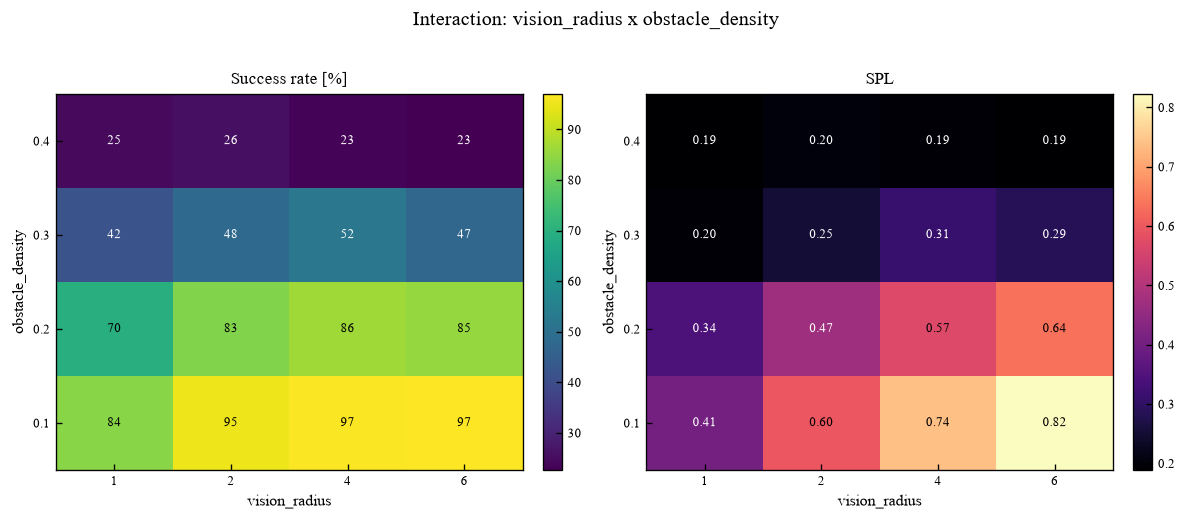

  saved c:\Users\simon\OneDrive - Alma Mater Studiorum Università di Bologna\Corsi\Artificial Intelligence\II Anno\II Semestre\Multi-Agent Systems\Multi-Agent-Systems-Project\testing_results\plots\fig_heatmap_vision_density.png


In [4]:
def plot_heatmap(name):
    p = os.path.join(CSV_DIR, f"heatmap_{name}.csv")
    if not os.path.exists(p):
        print("  (skip) no", p); return
    df = pd.read_csv(p)
    xname, yname = df.x_name.iloc[0], df.y_name.iloc[0]
    xs = sorted(df.x.unique()); ys = sorted(df.y.unique())

    def grid(col):
        g = np.full((len(ys), len(xs)), np.nan)
        for _, r in df.iterrows():
            g[ys.index(r.y), xs.index(r.x)] = r[col]
        return g

    fig, axs = plt.subplots(1, 2, figsize=(10.0, 4.2))
    for ax, (col, ttl, fmt, scale, cmap) in zip(
        axs, [("success_rate", "Success rate [%]", "{:.0f}", 100, "viridis"),
              ("spl",          "SPL",              "{:.2f}", 1,   "magma")]):
        g  = grid(col) * scale
        im = ax.imshow(g, origin="lower", aspect="auto", cmap=cmap)
        ax.set_xticks(range(len(xs))); ax.set_xticklabels(xs)
        ax.set_yticks(range(len(ys))); ax.set_yticklabels(ys)
        ax.set_xlabel(xname); ax.set_ylabel(yname); ax.set_title(ttl)
        ax.grid(False)
        vmid = np.nanmin(g) + 0.55*(np.nanmax(g)-np.nanmin(g))
        for iy in range(len(ys)):
            for ix in range(len(xs)):
                v = g[iy, ix]
                if not np.isnan(v):
                    ax.text(ix, iy, fmt.format(v), ha="center", va="center",
                            fontsize=8, color="white" if v < vmid else "black")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.suptitle(f"Interaction: {xname} x {yname}", fontsize=12, y=1.02)
    fig.tight_layout()
    out = os.path.join(PLOT_DIR, f"fig_heatmap_{name}.png")
    fig.savefig(out); plt.show(); print("  saved", out)

for nm in ["nagents_comm", "vision_density"]:
    plot_heatmap(nm)

## 4 — Summary table

In-distribution vs OOD aggregates per axis — the generalization-gap headline.

In [5]:
rows = []
for axis in ["n_agents", "vision", "comm", "density", "max_steps"]:
    df = load_agg(axis)
    if df is None:
        continue
    for label, sub in [("in-dist", df[df.in_dist == 1]), ("OOD", df[df.in_dist == 0])]:
        if sub.empty:
            continue
        rows.append({
            "axis": axis, "region": label,
            "success_%":  round(100*sub.success_rate.mean(), 1),
            "reward":     round(sub.mean_reward.mean(), 1),
            "coverage_%": round(100*sub.coverage.mean(), 1),
            "SPL":        round(sub.spl.mean(), 3),
        })
summary = pd.DataFrame(rows)
summary.to_csv(os.path.join(CSV_DIR, "summary_table.csv"), index=False)
summary

,axis,region,success_%,reward,coverage_%,SPL
0,n_agents,in-dist,82.7,74.1,52.6,0.475
1,n_agents,OOD,90.0,-18.5,55.0,0.625
2,vision,in-dist,84.5,57.1,55.3,0.526
3,vision,OOD,86.3,70.0,68.3,0.627
4,comm,in-dist,88.0,74.0,53.6,0.552
5,comm,OOD,88.4,74.9,53.9,0.554
6,density,in-dist,84.4,39.0,53.2,0.566
7,density,OOD,29.4,-502.8,28.5,0.223
8,max_steps,in-dist,77.4,66.6,51.0,0.500
